In [41]:
#Vizualize demand spatial distribution in Amsterdam emoped pilot to define the od layer

In [42]:
### Imports 
import os
import math
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as patches
import json

import pandas as pd
import re
import xml.etree.ElementTree as ET

sys.path.append('../../')
from script.conversion.bison.coordinates import rd_to_utm
from mnms.graph.layers import PublicTransportLayer, MultiLayerGraph, OriginDestinationLayer
from mnms.generation.roads import generate_pt_line_road, generate_one_zone
from mnms.generation.layers import generate_bbox_origin_destination_layer
from mnms.vehicles.veh_type import Tram, Metro, Bus
from mnms.generation.zones import generate_one_zone
from mnms.mobility_service.public_transport import PublicTransportMobilityService
from mnms.time import TimeTable, Dt, Time
from mnms.io.graph import load_graph, save_graph, save_odlayer
from mnms.tools.render import draw_roads, draw_line, draw_odlayer
from mnms.tools.geometry import points_in_polygon, get_bounding_box


In [43]:
### Parameters

# Files and directories
current_dir = os.getcwd()
indir = current_dir + '/inputs/'
outdir = current_dir + '/outputs/'
f = open('params.json')
params = json.load(f)

amsterdam_json_filepath = indir + params['fn_network'] # mlgraph with the road network only
ams_dmd_path = indir + params['fn_demand'] #'custom_demand_4-23.csv' # dmd for odlayer

In [44]:
### Get the MLGraph without TCs 
amsterdam_graph = load_graph(amsterdam_json_filepath)
roads = amsterdam_graph.roads

In [45]:
# Load dmd
db_dmd = pd.read_csv(ams_dmd_path, sep=';')

In [46]:
db_dmd

,ID,DEPARTURE,ORIGIN,DESTINATION
0,60932,16:00:01,629449.4523542934 5805424.096290749,626660.255009979 5802807.354844735
1,15003,16:00:03,629969.1678525544 5803086.982406631,626491.3286863616 5799474.939499609
2,50557,16:00:03,629168.6201565353 5806176.006280616,629407.3826460189 5804591.271653214
3,15619,16:00:04,630573.1180763138 5802415.502295327,632800.6057404992 5806536.994795652
4,8248,16:00:04,632872.2096571908 5801619.381775841,628672.6333212476 5800568.975816703
...,...,...,...,...
6554,12537,17:59:55,630770.0712266134 5799996.465275417,631017.807058996 5802800.962700652
6555,20790,17:59:57,632943.7803113076 5796698.617269829,634677.6942187406 5795210.434328123
6556,22189,17:59:58,633426.5642158828 5795721.359967507,634198.6827206486 5798384.496872034
6557,19224,17:59:58,630816.4694940925 5803024.790660395,633316.9710496576 5802004.910609437


In [47]:
nb_dmd = len(db_dmd)
origins = np.zeros((len(db_dmd),2))
destinations = np.zeros((len(db_dmd),2))
for i, row in db_dmd[:].iterrows():
    origins[i] = [float(o) for o in row['ORIGIN'].split(' ')]
    destinations[i] = [float(d) for d in row['DESTINATION'].split(' ')]

# Cluster

In [48]:
# Create clusters of OD
from sklearn.cluster import KMeans

In [49]:
all_od = np.zeros((2*nb_dmd,2))
all_od[:nb_dmd] = origins
all_od[nb_dmd:] = destinations

nb_clusters = 200

kmeans = KMeans(n_clusters = nb_clusters, random_state=0).fit([[x,y] for (x,y) in all_od])#, sample_weight=df_centroids['weight'].values)\n",





/Users/louis/opt/anaconda3/envs/mnms/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [50]:
od_clustered = kmeans.cluster_centers_

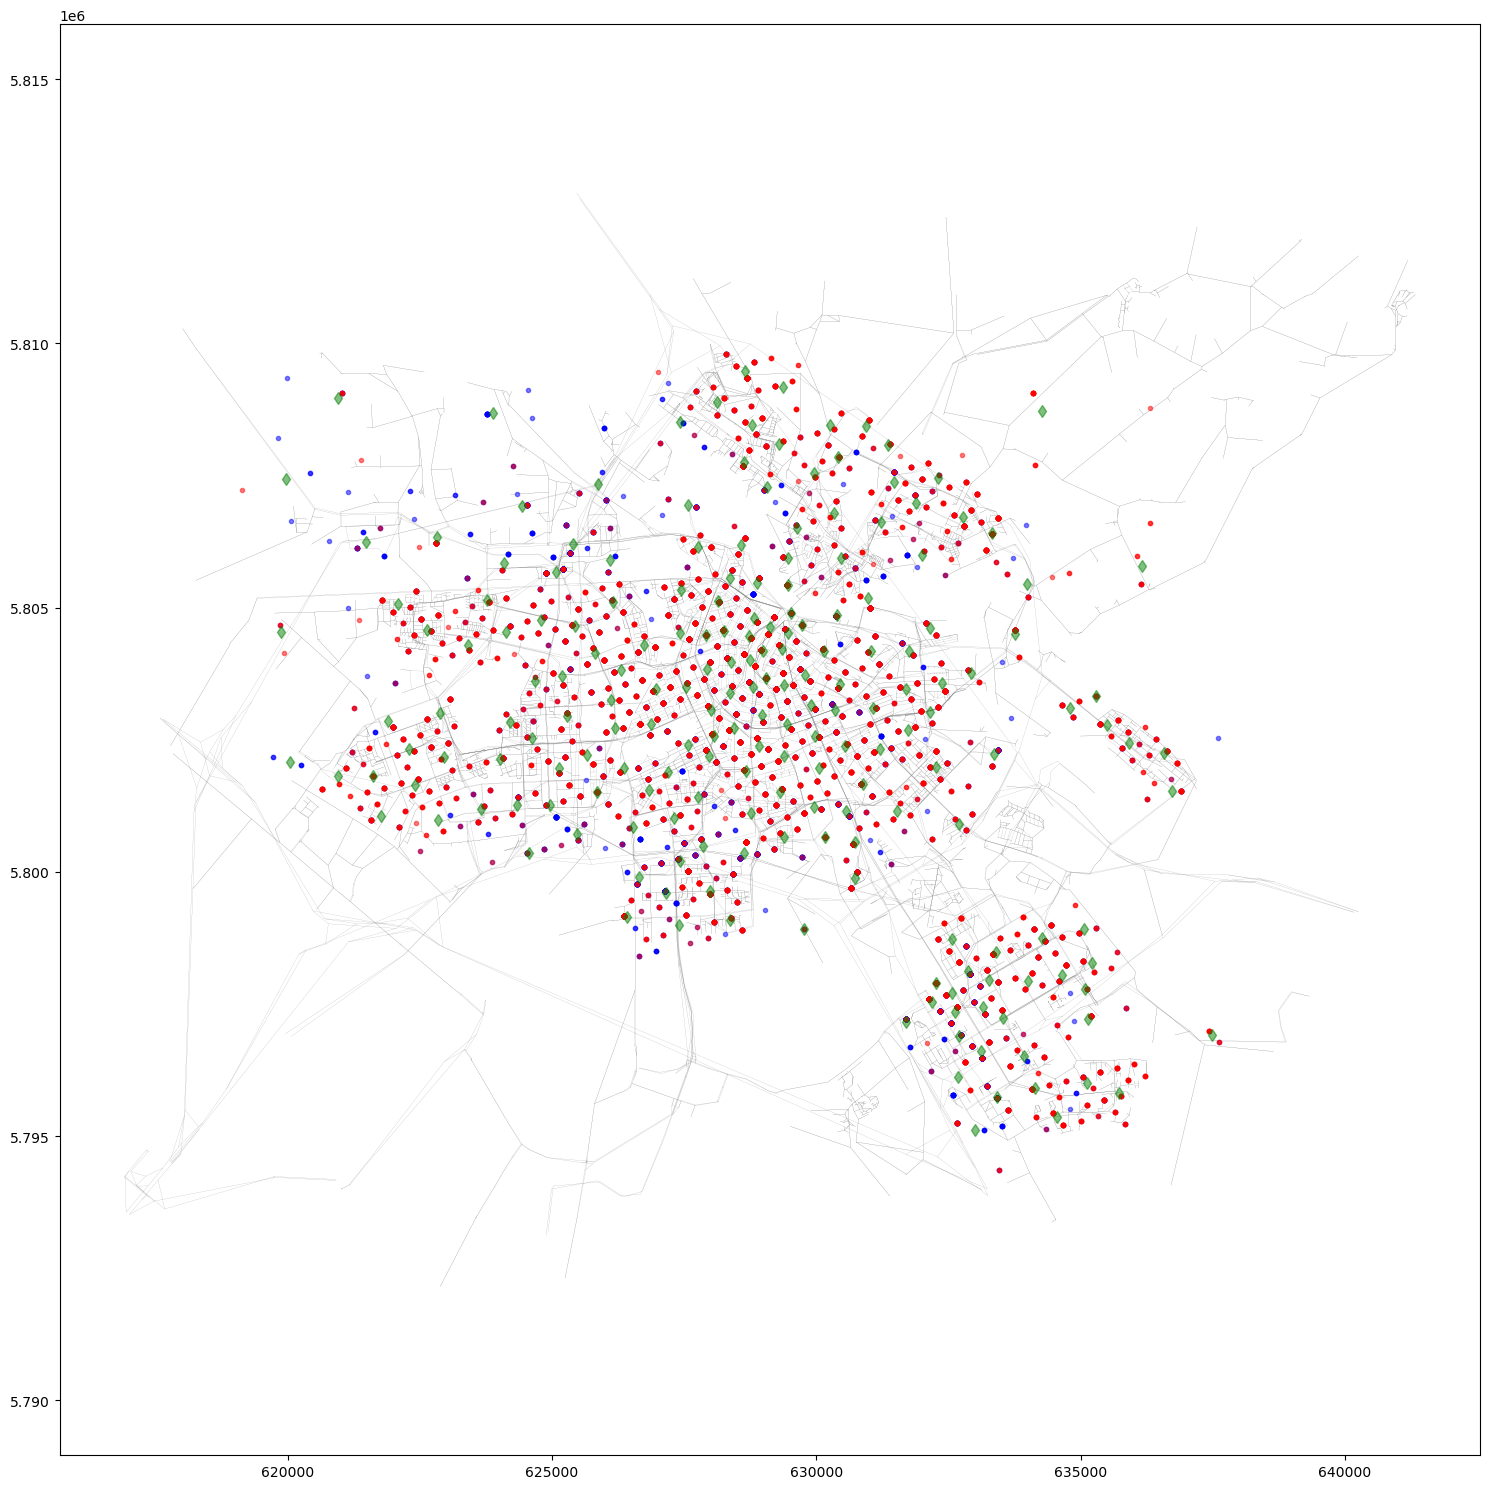

In [51]:
fig, ax = plt.subplots(figsize=(15, 15))
draw_roads(ax, roads, color='grey', linkwidth=0.1, nodesize=0, draw_stops=False, node_label=False)

plt.plot(origins[:,0], origins[:,1], 'b.', alpha=0.5)
plt.plot(destinations[:,0], destinations[:,1], 'r.', alpha=0.5)
plt.plot(od_clustered[:,0], od_clustered[:,1], 'gd', alpha=0.5)
#plt.xlim([624e3, 635e3])
#plt.ylim([5.795e6, 5.8125e6])

In [52]:
# Save odlayer
odlayer = OriginDestinationLayer()

for i, od in enumerate(od_clustered):
    odlayer.create_origin_node(f"ORIGIN_{i}", od)
    odlayer.create_destination_node(f"DESTINATION_{i}", od)

In [53]:
odlayer.origins

{'ORIGIN_0': array([ 632872.22339411, 5798120.52719036]),
 'ORIGIN_1': array([ 628005.97800888, 5803070.38731469]),
 'ORIGIN_2': array([ 623404.31199594, 5804300.15169548]),
 'ORIGIN_3': array([ 629466.84835007, 5804525.16391126]),
 'ORIGIN_4': array([ 631202.19329894, 5802326.63658365]),
 'ORIGIN_5': array([ 628626.80307834, 5807761.03880677]),
 'ORIGIN_6': array([ 627992.89688498, 5799639.00085528]),
 'ORIGIN_7': array([ 632296.8766752 , 5807446.85351268]),
 'ORIGIN_8': array([ 625806.38004114, 5804136.16541807]),
 'ORIGIN_9': array([ 636586.84129717, 5802248.66503379]),
 'ORIGIN_10': array([ 634140.77890504, 5795914.67983547]),
 'ORIGIN_11': array([ 622833.23874684, 5800986.86330041]),
 'ORIGIN_12': array([ 628253.14190221, 5804555.05131735]),
 'ORIGIN_13': array([ 632158.55281827, 5804611.98629751]),
 'ORIGIN_14': array([ 627762.12339084, 5801422.85068238]),
 'ORIGIN_15': array([ 626183.42889137, 5802727.20297388]),
 'ORIGIN_16': array([ 625405.10816555, 5806199.03389127]),
 'ORIGI

In [54]:
#save_odlayer(odlayer, indir + f'od_layer_clustered_{nb_clusters}.json')

# OD points

In [55]:
origins_str = [str(p[0])+','+str(p[1]) for p in origins]
destinations_str = [str(p[0])+','+str(p[1]) for p in destinations]

In [56]:
points_str = np.unique(origins_str + destinations_str)
points = [[float(pp) for pp in p.split(',')] for p in points_str]

In [57]:
len(points)

842

In [58]:
# Save odlayer
odlayer = OriginDestinationLayer()

for i, od in enumerate(points):
    odlayer.create_origin_node(f"ORIGIN_{i}", od)
    odlayer.create_destination_node(f"DESTINATION_{i}", od)

In [59]:
odlayer.origins

{'ORIGIN_0': [619131.9533648285, 5807224.170893929],
 'ORIGIN_1': [619722.7602578653, 5802167.623113418],
 'ORIGIN_2': [619819.6719324354, 5808217.8577584885],
 'ORIGIN_3': [619850.4260722174, 5804665.311892333],
 'ORIGIN_4': [619929.6184065838, 5804137.260604206],
 'ORIGIN_5': [619983.8922566546, 5809354.130677865],
 'ORIGIN_6': [620057.2227236249, 5806634.356294085],
 'ORIGIN_7': [620246.4401255952, 5802024.65134739],
 'ORIGIN_8': [620422.3565051515, 5807547.347466694],
 'ORIGIN_9': [620648.4030560774, 5801577.15546541],
 'ORIGIN_10': [620781.7076184329, 5806268.0196977835],
 'ORIGIN_11': [620971.15489204, 5801657.9149071565],
 'ORIGIN_12': [621030.8420518703, 5809068.839558484],
 'ORIGIN_13': [621092.9069435325, 5801962.431159319],
 'ORIGIN_14': [621141.1268336888, 5804988.431649602],
 'ORIGIN_15': [621146.8356751312, 5807181.082358597],
 'ORIGIN_16': [621172.1615525004, 5801434.14949311],
 'ORIGIN_17': [621214.6554633122, 5802266.939436379],
 'ORIGIN_18': [621257.1429131306, 580309

In [60]:
save_odlayer(odlayer, indir + 'od_layer_od.json')